In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [5]:
df = pd.read_csv('../../course_assignments/homework9/noisy_curvefit_data.csv')

In [13]:
shape = df.shape
print(f"Shape of the dataset: {shape}")
print(f"Number of rows: {shape[0]}")
print(f"Number of columns: {shape[1]}")
print("\nFirst five rows:")
print(df.head(5))
print("\nLast five rows:")
print(df.tail(5))
print("\nColumn names:", df.columns.tolist())

Shape of the dataset: (100, 6)
Number of rows: 100
Number of columns: 6

First five rows:
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113

Last five rows:
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850

Column names: ['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5

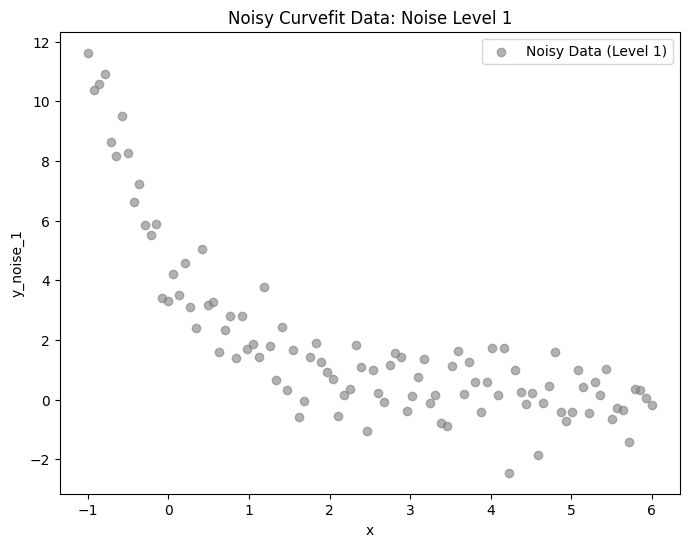

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(df['x'], df['y_noise_1'], color='gray', alpha=0.6, label='Noisy Data (Level 1)')
plt.xlabel('x')
plt.ylabel('y_noise_1')
plt.title('Noisy Curvefit Data: Noise Level 1')
plt.legend()
plt.show()

Fit: y = 4.71 * e^(-0.92 * x)
Reduced Chi-Squared: 0.7907


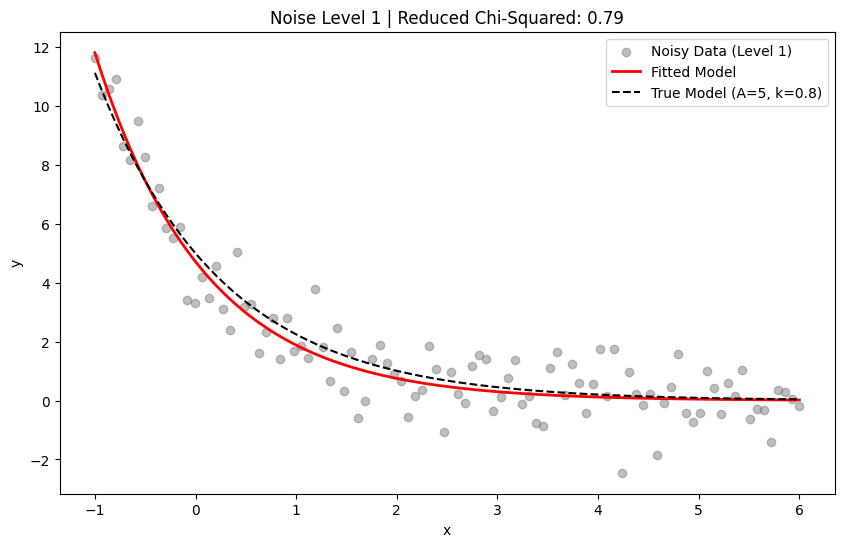

In [27]:
# --- 2.2 Fit the Data ---
#1
def model(x, A, k):
    return A * np.exp(-k * x)

#2
x_data = df['x']
y_data = df['y_noise_1']
p0 = [1, 1]  

#3
popt, pcov = curve_fit(model, x_data, y_data, p0=p0)

#4
A_fit, k_fit = popt
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

#5
residuals = y_data - model(x_data, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x_data) - len(popt)
chi2_reduced = chi2 / dof
print(f"Reduced Chi-Squared: {chi2_reduced:.4f}")

#6
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color='gray', alpha=0.5, label='Noisy Data (Level 1)')
y_fit = model(x_data, A_fit, k_fit)
plt.plot(x_data, y_fit, color='red', linewidth=2, label='Fitted Model')
y_true = model(x_data, 5, 0.8)
plt.plot(x_data, y_true, color='black', linestyle='--', label='True Model (A=5, k=0.8)')
plt.title(f"Noise Level 1 | Reduced Chi-Squared: {chi2_reduced:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

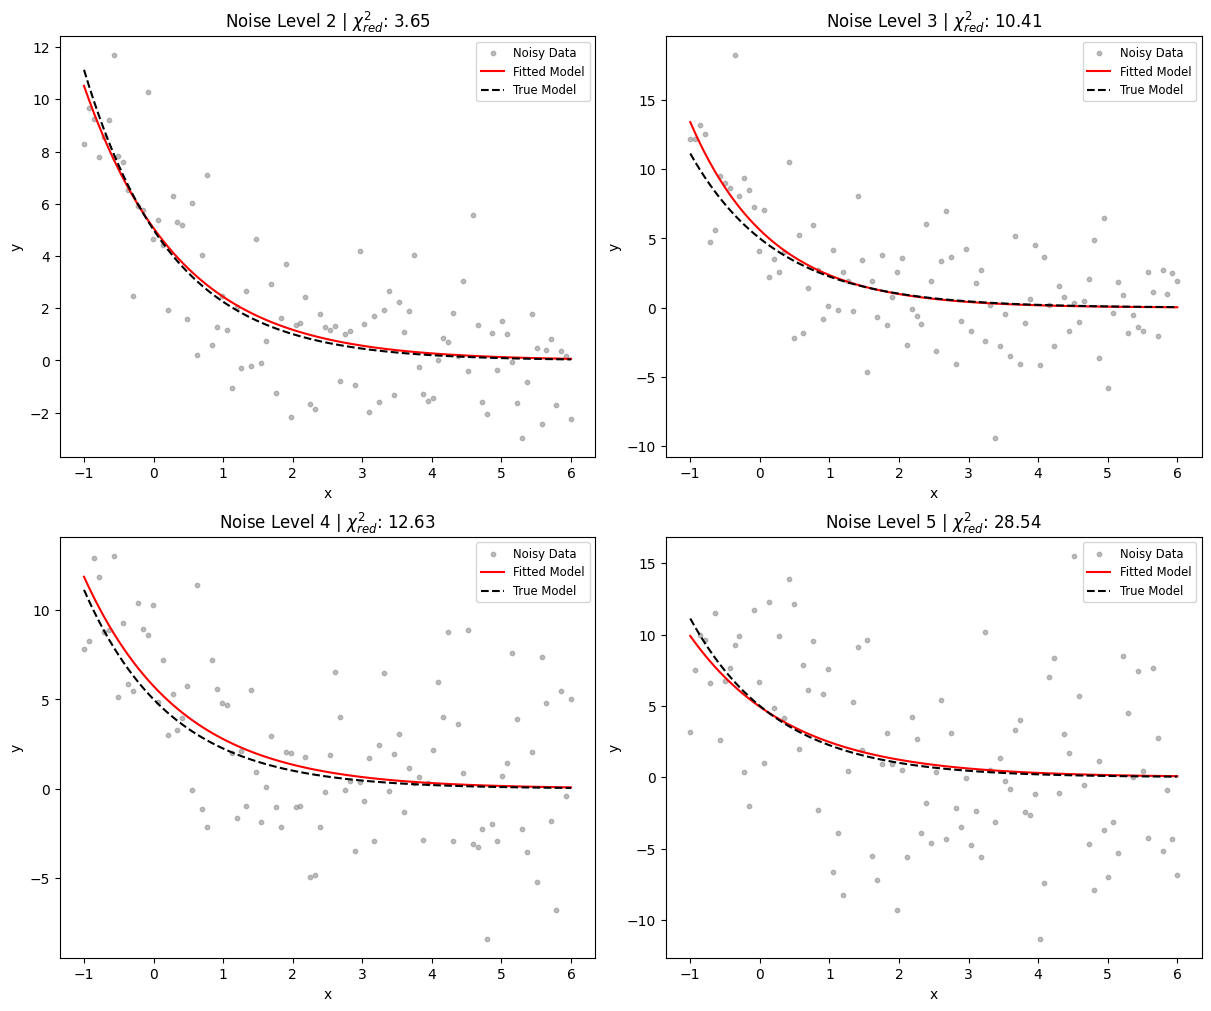

1. The red line drifts further from the black line as you increase the noise level because higher noise creates random clumps of data that pull the fit away from the true physics.
2. The reduced chi-squared increases drastically (from ~3.6 to ~28.5) as you increase the noise level because the dots are much further from the curve. Since the formula sums these distances, more of this scatter equals a much higher reduced chi-squared value.


In [30]:
# --- 2.3 Compare Different Noise Levels ---
# 1. 
def fit_model(x, y):
    popt, pcov = curve_fit(model, x, y, p0=[1, 1])
    
    residuals = y - model(x, *popt)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_red = chi2 / dof
    
    return popt, chi2_red

# 2. 
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axes = axes.flatten() 

# 3. 
noise_columns = ['y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']

for i, col_name in enumerate(noise_columns):
    x_vals = df['x']
    y_vals = df[col_name]
    
    best_params, red_chi = fit_model(x_vals, y_vals)
    
    axes[i].scatter(x_vals, y_vals, color='gray', alpha=0.5, label='Noisy Data', s=10)
    axes[i].plot(x_vals, model(x_vals, *best_params), color='red', label='Fitted Model')
    axes[i].plot(x_vals, model(x_vals, 5, 0.8), color='black', linestyle='--', label='True Model')
    
    noise_level = i + 2  
    axes[i].set_title(rf"Noise Level {noise_level} | $\chi^2_{{red}}$: {red_chi:.2f}")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")
    axes[i].legend(fontsize='small')

plt.show()

#4. 
print("1. The red line drifts further from the black line as you increase the noise level because higher noise creates random clumps of data that pull the fit away from the true physics.")
print("2. The reduced chi-squared increases drastically (from ~3.6 to ~28.5) as you increase the noise level because the dots are much further from the curve. Since the formula sums these distances, more of this scatter equals a much higher reduced chi-squared value.")

In [31]:
# --- 2.4 Save Your Results ---
results_list = []

for i in range(1, 6):
    col = f'y_noise_{i}'
    params, red_chi = fit_model(df['x'], df[col])
    
    results_list.append({
        "Noise level": i,
        "A fit": params[0],
        "k fit": params[1],
        "Reduced chi-squared": red_chi
    })

results_df = pd.DataFrame(results_list)

results_df.to_csv("noisy_parameters.csv", index=False)

results_df

,Noise level,A fit,k fit,Reduced chi-squared
0,1,4.714814,0.918308,0.790673
1,2,5.063889,0.730396,3.649382
2,3,5.609396,0.870372,10.410207
3,4,5.738727,0.725965,12.626832
4,5,4.943458,0.695012,28.538124
